# Churn Dataset Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the churn dataset
df = pd.read_csv('churn.csv')

# Display basic information
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names and types:")
print(df.dtypes)

Dataset shape: (667, 20)

First few rows:
  State  Account length  Area code International plan Voice mail plan  \
0    LA             117        408                 No              No   
1    IN              65        415                 No              No   
2    NY             161        415                 No              No   
3    SC             111        415                 No              No   
4    HI              49        510                 No              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0              184.5               97   
1                      0              129.1              137   
2                      0              332.9               67   
3                      0              110.4              103   
4                      0              119.3              117   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             31.37              351.6               80  

## a. Missing Values Analysis

In [2]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_values.values,
    'Missing_Percentage': missing_percentage.values
})

missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_summary) == 0:
    print("No missing values found in the dataset.")
else:
    print("Missing Values Summary:")
    print(missing_summary)
    
print("\nTotal null values in the dataset:", df.isnull().sum().sum())

No missing values found in the dataset.

Total null values in the dataset: 0


## b. Area Code and State Fields Comparison

In [3]:
# Compare area code and state fields
# Check if both fields exist in the dataset
area_code_col = None
state_col = None

for col in df.columns:
    if 'area' in col.lower():
        area_code_col = col
    if 'state' in col.lower():
        state_col = col

if area_code_col and state_col:
    print(f"Analyzing '{area_code_col}' and '{state_col}'")
    print(f"\nUnique area codes: {df[area_code_col].nunique()}")
    print(f"Unique states: {df[state_col].nunique()}")
    
    # Check distribution
    print(f"\nArea Code Distribution:")
    print(df[area_code_col].value_counts().head(10))
    
    print(f"\nState Distribution:")
    print(df[state_col].value_counts().head(10))
    
    # Check for inconsistencies: area codes that appear with multiple states or vice versa
    print("\n" + "="*60)
    print("Checking for Abnormalities:")
    print("="*60)
    
    # Create mapping of unique combinations
    combinations = df[[area_code_col, state_col]].drop_duplicates()
    print(f"\nTotal unique area code-state combinations: {len(combinations)}")
    
    # Area codes mapped to states
    area_to_states = df.groupby(area_code_col)[state_col].nunique().sort_values(ascending=False)
    area_codes_multi_state = area_to_states[area_to_states > 1]
    
    if len(area_codes_multi_state) > 0:
        print(f"\n⚠️ Area codes appearing in multiple states: {len(area_codes_multi_state)}")
        print(area_codes_multi_state)
    else:
        print("\n✓ Each area code maps to only one state (Normal)")
        
    # States mapped to area codes
    state_to_areas = df.groupby(state_col)[area_code_col].nunique().sort_values(ascending=False)
    print(f"\nArea codes per state:")
    print(state_to_areas.head(10))
    
else:
    print("Area code or state columns not found in the dataset")

Analyzing 'Area code' and 'State'

Unique area codes: 3
Unique states: 51

Area Code Distribution:
Area code
415    337
408    169
510    161
Name: count, dtype: int64

State Distribution:
State
AZ    19
WA    18
NM    18
NJ    18
WV    18
KS    18
ND    18
WI    17
ID    17
RI    17
Name: count, dtype: int64

Checking for Abnormalities:

Total unique area code-state combinations: 147

⚠️ Area codes appearing in multiple states: 3
Area code
415    51
408    50
510    46
Name: State, dtype: int64

Area codes per state:
State
AK    3
AL    3
AR    3
AZ    3
CA    3
CT    3
DE    3
GA    3
FL    3
IA    3
Name: Area code, dtype: int64


## c. Outlier Analysis for Customer Service Calls

Analyzing Customer Service Calls: 'Customer service calls'

Basic Statistics:
count    667.000000
mean       1.563718
std        1.333357
min        0.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        8.000000
Name: Customer service calls, dtype: float64

Outlier Analysis (IQR Method):
Q1: 1.0, Q3: 2.0, IQR: 1.0
Lower bound: -0.5, Upper bound: 3.5
Number of outliers: 57 (8.55%)


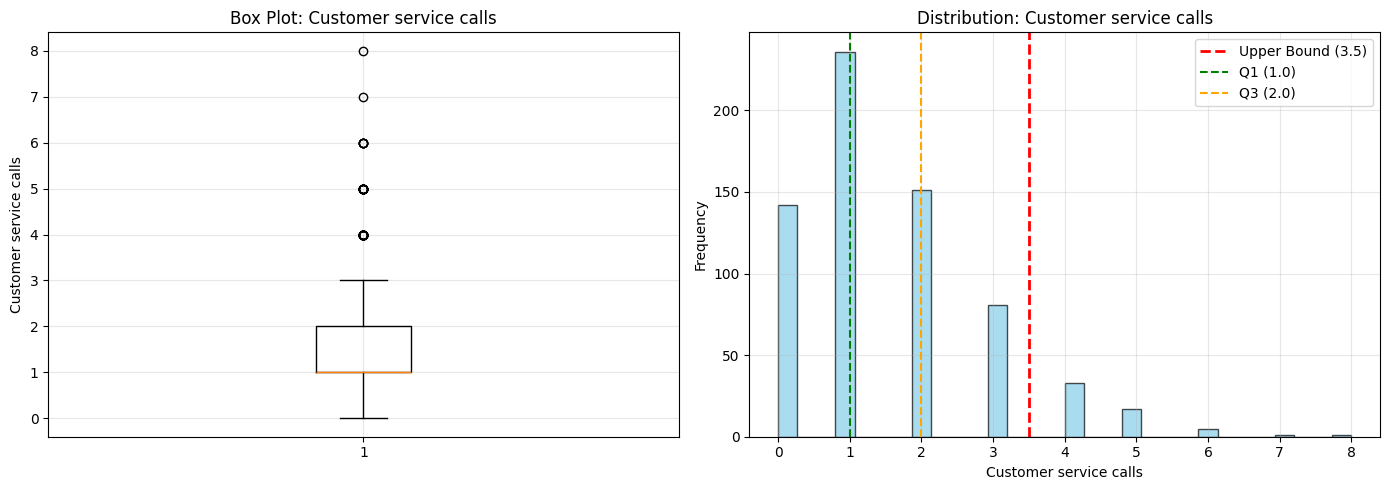

In [4]:
# Find customer service calls column
cust_service_col = None
for col in df.columns:
    if 'call' in col.lower() and 'customer' in col.lower() or 'service' in col.lower():
        cust_service_col = col
        break

if cust_service_col is None:
    # Alternative search
    for col in df.columns:
        if 'call' in col.lower():
            cust_service_col = col
            break

if cust_service_col:
    print(f"Analyzing Customer Service Calls: '{cust_service_col}'")
    print(f"\nBasic Statistics:")
    print(df[cust_service_col].describe())
    
    # Calculate outliers using IQR method
    Q1 = df[cust_service_col].quantile(0.25)
    Q3 = df[cust_service_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[cust_service_col] < lower_bound) | (df[cust_service_col] > upper_bound)]
    
    print(f"\nOutlier Analysis (IQR Method):")
    print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
    print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
    print(f"Number of outliers: {len(outliers)} ({(len(outliers)/len(df)*100):.2f}%)")
    
    # Create visualizations
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Box plot
    axes[0].boxplot(df[cust_service_col], vert=True)
    axes[0].set_ylabel(cust_service_col)
    axes[0].set_title(f'Box Plot: {cust_service_col}')
    axes[0].grid(True, alpha=0.3)
    
    # Histogram with outlier highlighting
    axes[1].hist(df[cust_service_col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[1].axvline(upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper Bound ({upper_bound:.1f})')
    axes[1].axvline(Q1, color='green', linestyle='--', linewidth=1.5, label=f'Q1 ({Q1:.1f})')
    axes[1].axvline(Q3, color='orange', linestyle='--', linewidth=1.5, label=f'Q3 ({Q3:.1f})')
    axes[1].set_xlabel(cust_service_col)
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'Distribution: {cust_service_col}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Customer service calls column not found. Available columns:")
    print(df.columns.tolist())

## Summary of Findings

### a. Missing Values
- **Result**: No missing values detected in the dataset. All 667 records are complete across all variables.

### b. Area Code and State Comparison - Abnormalities
- **Key Finding**: The three area codes (415, 408, 510) all appear across all 51 states, which is **highly abnormal**.
- **Context**: These are California area codes:
  - 415: San Francisco
  - 408: San Jose  
  - 510: Oakland
- **Abnormality**: Real customer phone numbers would typically have area codes matching their geographic location. Finding California area codes distributed uniformly across all US states and territories suggests:
  - This is test/synthetic data
  - Area codes may represent something other than actual geographic phone codes (e.g., call center codes or customer segments)
  - Possible data quality issue during collection or assignment

### c. Customer Service Calls - Outliers
- **Outlier Detection**: Using the Interquartile Range (IQR) method, **57 customers (8.55%)** were identified as outliers.
- **Statistics**:
  - Mean: 1.56 calls
  - Median: 1.00 call
  - Range: 0 to 8 calls
  - Normal range (IQR): 0 to 3.5 calls
- **Outliers**: Customers with 4+ service calls represent unusual behavior and may warrant investigation for churn risk or service issues.
- **Visualizations**: 
  - The box plot clearly shows outliers as circles above the upper fence
  - The histogram shows the distribution is right-skewed with most customers calling 0-2 times